# Machine Learning #06 — Recurrent Neural Networks in PyTorch 🔁
Today we move to **Recurrent Neural Networks (RNNs)** — networks that have a **memory** and can
process **sequences** (text, time series, audio…).

Our task: **classify tweets** as *hate speech* (`1`) or *neutral* (`0`).

We will walk through the **complete PyTorch sequence workflow**:

> **raw text → clean tokens → vocabulary → padded tensors → embedding → RNN (LSTM + GRU) → prediction**

## What is an RNN? 🧠

### 1. How is an RNN different from a feed-forward network (FCNN)?

A classic feed-forward network processes every input **independently** — it does
not care what came before. An **RNN has a memory**: a **hidden state**
$h_t$ that is passed from one step of the sequence to the next.

$$h_t = f(W_x\,x_t + W_h\,h_{t-1} + b)$$

Thanks to this loop it can capture **dependencies over time** — for example that
the word *"not"* before *"good"* flips the whole meaning of a sentence.

| | Feed-forward (FCNN) | Recurrent (RNN) |
|---|---|---|
| Input | one fixed vector | a **sequence** of vectors |
| Memory | none | **hidden state** carried step by step |
| Typical use | tabular data | text, time series, speech |

### 2. Pure RNN vs. LSTM / GRU — what problem do they solve?

A **pure RNN** suffers from the **vanishing gradient** problem: when we
back-propagate through many time steps, the gradient shrinks exponentially, so
the network effectively **forgets** information from far back in the sequence.

- **LSTM** (Long Short-Term Memory) solves this with **gates** (input, forget,
  output) and a separate long-term **cell state** $c_t$. It decides what to
  remember and what to forget. 🔒
- **GRU** (Gated Recurrent Unit) is a **simpler** LSTM with only two gates —
  lighter to compute, usually just as good in practice. ⚡

## Imports and setup ⚙️

Remember to switch the Colab runtime to **GPU**! *(Runtime → Change runtime type → GPU)*

In [ ]:
!pip install textblob -q

In [1]:
import unicodedata, re, string, itertools
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from textblob import TextBlob
from nltk.stem import WordNetLemmatizer

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

sns.set_theme(style="whitegrid")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch version:", torch.__version__)
print("device:", device)

torch version: 2.6.0+cu124
device: cuda


In [2]:
# NLTK / TextBlob need a few data packages for tokenization and lemmatization
#nltk.download("punkt")
nltk.download("punkt_tab")
#nltk.download("wordnet")
#nltk.download("omw-1.4")


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\recka\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

## How an LSTM sees a sequence 🔬

Before touching real data, let's understand the **single most confusing thing**
about RNNs in PyTorch: **the shapes**.

An `nn.LSTM` (with `batch_first=True`) expects input of shape:

$$(\text{batch},\ \text{sequence length},\ \text{features})$$

and returns **two** things:

- **`output`** — the hidden state at **every** time step
  → shape `(batch, seq_len, hidden)` 
- **`(h_n, c_n)`** — the **last** hidden state `h_n` and cell state `c_n`
  → shape `(num_layers, batch, hidden)` 

In [3]:
# A fake "batch of 2 sequences, each 4 steps long, each step a 3-number vector"
demo_lstm = nn.LSTM(input_size=3, hidden_size=5, batch_first=True)

dummy = torch.randn(2, 4, 3)          # (batch=2, seq_len=4, features=3)
output, (h_n, c_n) = demo_lstm(dummy)

print("input   :", tuple(dummy.shape),  "-> (batch, seq_len, features)")
print("output  :", tuple(output.shape), "-> hidden state at EVERY step")
print("h_n     :", tuple(h_n.shape),    "-> LAST hidden state (a summary of the whole sequence)")
print("c_n     :", tuple(c_n.shape),    "-> LAST cell state (LSTM's long-term memory)")

input   : (2, 4, 3) -> (batch, seq_len, features)
output  : (2, 4, 5) -> hidden state at EVERY step
h_n     : (1, 2, 5) -> LAST hidden state (a summary of the whole sequence)
c_n     : (1, 2, 5) -> LAST cell state (LSTM's long-term memory)


> 💡 **Key idea:** for classification we usually only need **`h_n`** — the
> single vector that summarises the whole sequence. We will feed that into a
> small linear layer to get the final prediction.

## The dataset 📊

**Source:** tweets labelled for hate-speech detection
(`train_tweets.csv` from the course repository).

| Column | Meaning |
|---|---|
| `tweet` | raw tweet text |
| `label` | `0` = neutral, `1` = hate speech |

In [4]:
df = pd.read_csv("https://github.com/rasvob/VSB-FEI-Deep-Learning-Exercises/raw/main/datasets/train_tweets.csv")
df.head()

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [5]:
df.shape

(31962, 3)

### 🔎 A quick look — how imbalanced is it?

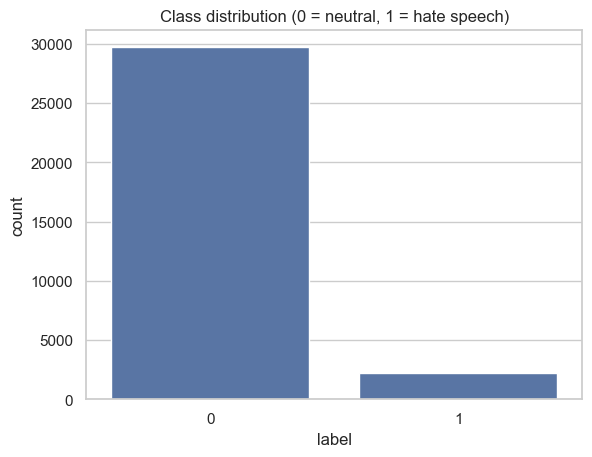

label
0    29720
1     2242
Name: count, dtype: int64


In [6]:
sns.countplot(x="label", data=df)
plt.title("Class distribution (0 = neutral, 1 = hate speech)")
plt.show()

print(df.label.value_counts())

### 🔎 Tweet length is similar in both classes

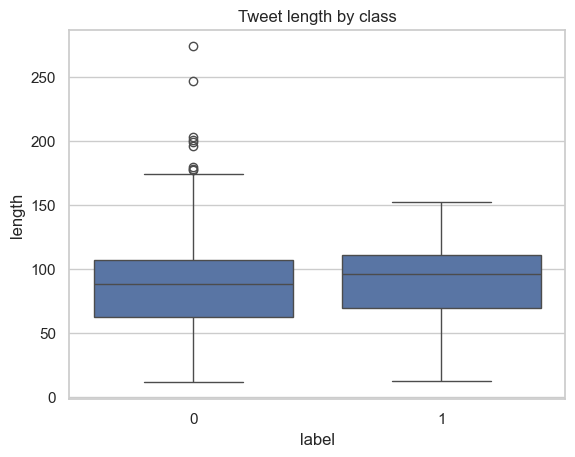

In [7]:
df["length"] = df.tweet.apply(len)
sns.boxplot(x="label", y="length", data=df)
plt.title("Tweet length by class")
plt.show()

### The raw text is very noisy

Take a look at a few examples — mentions (`@user`), punctuation, weird casing,
contractions… This is why we need a preprocessing pipeline.

In [8]:
for t in df.loc[:10, "tweet"]:
    print(t)

 @user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction.   #run
@user @user thanks for #lyft credit i can't use cause they don't offer wheelchair vans in pdx.    #disapointed #getthanked
  bihday your majesty
#model   i love u take with u all the time in urð±!!! ððððð¦ð¦ð¦  
 factsguide: society now    #motivation
[2/2] huge fan fare and big talking before they leave. chaos and pay disputes when they get there. #allshowandnogo  
 @user camping tomorrow @user @user @user @user @user @user @user dannyâ¦
the next school year is the year for exams.ð¯ can't think about that ð­ #school #exams   #hate #imagine #actorslife #revolutionschool #girl
we won!!! love the land!!! #allin #cavs #champions #cleveland #clevelandcavaliers  â¦ 
 @user @user welcome here !  i'm   it's so #gr8 ! 
 â #ireland consumer price index (mom) climbed from previous 0.2% to 0.5% in may   #blog #silver #gold #forex


## Text preprocessing 🧹

A neural network cannot read raw strings. We turn each tweet into a **clean list
of tokens (words)**. We apply, in order:

1. **Tokenize** the tweet into words (TextBlob).
2. **Remove non-ASCII** characters (emoji, accents…).
3. **Lowercase** everything.
4. **Remove numbers**.
5. **Remove punctuation** (leftover symbols like `/`, `-`, `.`.
   becomes a bare `/` after step 4, which we drop here).
6. **Remove the `user`** token (every mention became `user` after cleaning — it
   carries no sentiment).
7. **Fix broken contractions** (e.g. `do` + `n't` → `don't`).


In [ ]:
def form_sentence(tweet):
    """Tokenize a raw tweet into a list of words using TextBlob."""
    return list(TextBlob(tweet).words)

def remove_non_ascii(words):
    """Drop non-ASCII characters (emoji, accents, special symbols)."""
    out = []
    for w in words:
        w = unicodedata.normalize("NFKD", w).encode("ascii", "ignore").decode("utf-8", "ignore")
        out.append(w)
    return out

def to_lowercase(words):
    return [w.lower() for w in words]

def remove_numbers(words):
    """Remove digits; keep the word only if something is left."""
    out = []
    for w in words:
        w = re.sub(r"\d+", "", w)
        if w != "":
            out.append(w)
    return out

def remove_punctuation(words):
    """Strip leading/trailing punctuation from each token; drop tokens left empty."""
    out = []
    for w in words:
        w = w.strip(string.punctuation)
        if w != "":
            out.append(w)
    return out

def normalize(words):
    words = remove_non_ascii(words)
    words = to_lowercase(words)
    words = remove_numbers(words)
    words = remove_punctuation(words) 
    return words

def fix_nt(words):
    """Merge a stray "n't" back onto the previous word: [do, n't] -> [don't]."""
    res = []
    for w in words:
        if w in ("n't", "nt") and res:
            res[-1] = res[-1] + "n't"   # attach onto the previous word
        else:
            res.append(w)
    return res

### Apply the pipeline step by step 🧼

We build up new columns so you can **see** the effect of each stage.

In [24]:
# 1) tokenize
df["Words"] = df["tweet"].apply(form_sentence)
df.loc[:5,  ["tweet", "Words"]]

,tweet,Words
0,@user when a father is dysfunctional and is s...,"[user, when, a, father, is, dysfunctional, and..."
1,@user @user thanks for #lyft credit i can't us...,"[user, user, thanks, for, lyft, credit, i, ca,..."
2,bihday your majesty,"[bihday, your, majesty]"
3,#model i love u take with u all the time in ...,"[model, i, love, u, take, with, u, all, the, t..."
4,factsguide: society now #motivation,"[factsguide, society, now, motivation]"
5,[2/2] huge fan fare and big talking before the...,"[2/2, huge, fan, fare, and, big, talking, befo..."


In [25]:
# 2-5) normalize (non-ascii, lowercase, numbers, punctuation)
df["Words_normalized"] = df["Words"].apply(normalize)
df.loc[:5,  ["tweet", "Words", "Words_normalized"]]

,tweet,Words,Words_normalized
0,@user when a father is dysfunctional and is s...,"[user, when, a, father, is, dysfunctional, and...","[user, when, a, father, is, dysfunctional, and..."
1,@user @user thanks for #lyft credit i can't us...,"[user, user, thanks, for, lyft, credit, i, ca,...","[user, user, thanks, for, lyft, credit, i, ca,..."
2,bihday your majesty,"[bihday, your, majesty]","[bihday, your, majesty]"
3,#model i love u take with u all the time in ...,"[model, i, love, u, take, with, u, all, the, t...","[model, i, love, u, take, with, u, all, the, t..."
4,factsguide: society now #motivation,"[factsguide, society, now, motivation]","[factsguide, society, now, motivation]"
5,[2/2] huge fan fare and big talking before the...,"[2/2, huge, fan, fare, and, big, talking, befo...","[huge, fan, fare, and, big, talking, before, t..."


In [26]:
# 6) remove the 'user' token
df["Words_normalized_no_user"] = df["Words_normalized"].apply(lambda ws: [w for w in ws if "user" not in w])
df.loc[:5,  ["tweet", "Words_normalized", "Words_normalized_no_user"]]

,tweet,Words_normalized,Words_normalized_no_user
0,@user when a father is dysfunctional and is s...,"[user, when, a, father, is, dysfunctional, and...","[when, a, father, is, dysfunctional, and, is, ..."
1,@user @user thanks for #lyft credit i can't us...,"[user, user, thanks, for, lyft, credit, i, ca,...","[thanks, for, lyft, credit, i, ca, n't, use, c..."
2,bihday your majesty,"[bihday, your, majesty]","[bihday, your, majesty]"
3,#model i love u take with u all the time in ...,"[model, i, love, u, take, with, u, all, the, t...","[model, i, love, u, take, with, u, all, the, t..."
4,factsguide: society now #motivation,"[factsguide, society, now, motivation]","[factsguide, society, now, motivation]"
5,[2/2] huge fan fare and big talking before the...,"[huge, fan, fare, and, big, talking, before, t...","[huge, fan, fare, and, big, talking, before, t..."


In [29]:
# 7) fix contractions
df["Words_clean"] = df["Words_normalized_no_user"].apply(fix_nt)

df.loc[:5, ["tweet", "Words_normalized_no_user", "Words_clean"]]

,tweet,Words_normalized_no_user,Words_clean
0,@user when a father is dysfunctional and is s...,"[when, a, father, is, dysfunctional, and, is, ...","[when, a, father, is, dysfunctional, and, is, ..."
1,@user @user thanks for #lyft credit i can't us...,"[thanks, for, lyft, credit, i, ca, n't, use, c...","[thanks, for, lyft, credit, i, can't, use, cau..."
2,bihday your majesty,"[bihday, your, majesty]","[bihday, your, majesty]"
3,#model i love u take with u all the time in ...,"[model, i, love, u, take, with, u, all, the, t...","[model, i, love, u, take, with, u, all, the, t..."
4,factsguide: society now #motivation,"[factsguide, society, now, motivation]","[factsguide, society, now, motivation]"
5,[2/2] huge fan fare and big talking before the...,"[huge, fan, fare, and, big, talking, before, t...","[huge, fan, fare, and, big, talking, before, t..."


> 💡 Each tweet is now a **clean list of tokens**. This list-of-tokens form is
> exactly what we need to build a vocabulary next.

## A look at the vocabulary 🔤

Let's see the corpus size and the most common words.

In [30]:
all_words = list(itertools.chain(*df.Words_clean))   # flatten list-of-lists into one big list
all_words[:20]

['when',
 'a',
 'father',
 'is',
 'dysfunctional',
 'and',
 'is',
 'so',
 'selfish',
 'he',
 'drags',
 'his',
 'kids',
 'into',
 'his',
 'dysfunction',
 'run',
 'thanks',
 'for',
 'lyft']

In [31]:
dist = nltk.FreqDist(all_words)
dist

FreqDist({'the': 10168, 'to': 9836, 'a': 8881, 'i': 7187, 'you': 5894, 'and': 4906, 'in': 4653, 'for': 4497, 'is': 4186, 'of': 4170, ...})

In [33]:
print("Total tokens :", len(all_words))
print("Unique tokens:", len(dist))
print("Longest tweet:", max(df.Words_clean.apply(len)), "tokens")


Total tokens : 396306
Unique tokens: 40702
Longest tweet: 43 tokens


## From words to numbers 🔢

The network works with **integers**, not strings. We build a **vocabulary** that
maps each word to an index. Two indices are special:

| Index | Token | Meaning |
|---|---|---|
| `0` | `<pad>` | padding (to make sequences equal length) |
| `1` | `<unk>` | unknown word (not in the vocabulary / rare) |

We keep only the **`VOCAB_SIZE` most common** words — rarer words become `<unk>`.

This is the manual PyTorch equivalent of Keras' `TextVectorization` layer.

In [34]:
VOCAB_SIZE = 10000        # keep the 10k most frequent words
PAD_TOKEN, UNK_TOKEN = "<pad>", "<unk>"

# most common words first, leaving room for the 2 special tokens
most_common = [w for w, _ in dist.most_common(VOCAB_SIZE - 2)]
vocab = [PAD_TOKEN, UNK_TOKEN] + most_common

word2idx = {w: i for i, w in enumerate(vocab)}
PAD_IDX = word2idx[PAD_TOKEN]
UNK_IDX = word2idx[UNK_TOKEN]

print("Vocabulary size:", len(vocab))
print("First 10 tokens:", vocab[:10])

Vocabulary size: 10000
First 10 tokens: ['<pad>', '<unk>', 'the', 'to', 'a', 'i', 'you', 'and', 'in', 'for']


In [35]:
def numericalize(tokens):
    """Convert a list of words into a list of integer indices."""
    return [word2idx.get(w, UNK_IDX) for w in tokens]

# quick check on one tweet
example = df.Words_clean.iloc[0]
print("tokens :", example)
print("indices:", numericalize(example))

tokens : ['when', 'a', 'father', 'is', 'dysfunctional', 'and', 'is', 'so', 'selfish', 'he', 'drags', 'his', 'kids', 'into', 'his', 'dysfunction', 'run']
indices: [35, 4, 78, 10, 1, 7, 10, 22, 2615, 76, 6304, 100, 256, 257, 100, 7695, 471]


### Train / validation / test split 🎯

We split **with stratification** into train / val / test.


In [36]:
# stratified split: 80% train+val, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    df.Words_clean, df.label, test_size=0.20, random_state=SEED, stratify=df.label
)
# from the 80%, carve out 10% for validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.10, random_state=SEED, stratify=y_train
)

print("train:", len(X_train), "| val:", len(X_val), "| test:", len(X_test))
print("\nTrain label counts:\n", y_train.value_counts())

train: 23012 | val: 2557 | test: 6393

Train label counts:
 label
0    21397
1     1615
Name: count, dtype: int64


## Dataset & DataLoader — batching variable-length sequences 📦

Tweets have **different lengths**, but a batch tensor must be **rectangular**.
The clean PyTorch solution has three parts:

1. A **`Dataset`** that returns one `(sequence, label)` at a time.
2. A **`collate_fn`** that, for each batch, **pads** the shorter sequences with
   `<pad>` so they all match the longest one — and records the **real lengths**.
3. Later, inside the model, we use **`pack_padded_sequence`** so the RNN
   **ignores the padding** and only processes the real tokens. This is the
   *correct* way to handle padding (it does not waste computation on `<pad>` and
   does not pollute the hidden state). ✅

In [37]:
class TweetDataset(Dataset):
    def __init__(self, token_lists, labels):
        # store each tweet as a LongTensor of word indices (variable length)
        self.sequences = [torch.tensor(numericalize(toks), dtype=torch.long) for toks in token_lists]
        self.labels    = torch.tensor(list(labels), dtype=torch.float32)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, i):
        return self.sequences[i], self.labels[i]

In [38]:
def collate_fn(batch):
    """Turn a list of (sequence, label) into padded batch tensors."""
    sequences, labels = zip(*batch)
    lengths = torch.tensor([len(s) for s in sequences], dtype=torch.long)  # real length of each tweet
    # pad every sequence to the length of the longest one in THIS batch
    padded  = pad_sequence(sequences, batch_first=True, padding_value=PAD_IDX)
    labels  = torch.stack(labels).unsqueeze(1)   # shape (batch, 1) to match the model output
    return padded, lengths, labels

> ⚠️ Some tweets may become **empty** after cleaning (length 0), which breaks
> packing. We drop those before building the datasets.

In [39]:
# guard: pack_padded_sequence cannot handle length-0 sequences
def drop_empty(X, y):
    keep = X.apply(len) > 0
    return X[keep], y[keep]

X_train, y_train = drop_empty(X_train, y_train)
X_val,   y_val   = drop_empty(X_val,   y_val)
X_test,  y_test  = drop_empty(X_test,  y_test)

BATCH_SIZE = 128

train_ds = TweetDataset(X_train, y_train)
val_ds   = TweetDataset(X_val,   y_val)
test_ds  = TweetDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

# peek at one batch
xb, lengths, yb = next(iter(train_loader))
print("padded batch :", tuple(xb.shape), "-> (batch, longest_seq_in_batch)")
print("lengths      :", tuple(lengths.shape), "e.g.", lengths[:5].tolist())
print("labels       :", tuple(yb.shape))

padded batch : (128, 27) -> (batch, longest_seq_in_batch)
lengths      : (128,) e.g. [8, 13, 12, 20, 6]
labels       : (128, 1)


## Build the RNN 🏗️

Our model:

$$\text{indices} \rightarrow \textbf{Embedding} \rightarrow \textbf{LSTM} \rightarrow \textbf{GRU} \rightarrow \text{last hidden state} \rightarrow \textbf{Linear} \rightarrow \text{logit}$$

- **`nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)`** — turns each word
  index into a trainable `embed_dim`-vector. `padding_idx` keeps the `<pad>`
  vector fixed at zero. 🎯
- **`nn.LSTM` → `nn.GRU`** — two stacked recurrent layers. The LSTM passes its
  full per-step output to the GRU (like `return_sequences=True`), and we take the
  GRU's **last hidden state** as the sequence summary (like `return_sequences=False`).
- Inside `forward` we **pack** the padded batch so the RNN skips `<pad>` tokens.

We write it as an **`nn.Module` class** because the packing
logic lives naturally inside `forward`.

In [40]:
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim,  hidden_dim, batch_first=True)
        self.gru  = nn.GRU(hidden_dim,  hidden_dim, batch_first=True)
        self.fc1  = nn.Linear(hidden_dim, 64)
        self.drop = nn.Dropout(0.3)
        self.fc2  = nn.Linear(64, 1)      # single output logit

    def forward(self, x, lengths):
        emb = self.embedding(x)                              # (batch, seq, embed_dim)

        # PACK: tell the RNN the real length of each sequence so it ignores <pad>
        packed = pack_padded_sequence(emb, lengths.cpu(), batch_first=True, enforce_sorted=False)

        packed_out, _ = self.lstm(packed)                    # LSTM over the packed sequence
        _, h_n        = self.gru(packed_out)                 # GRU; h_n = last hidden state

        summary = h_n[-1]                                    # (batch, hidden) -> last layer's hidden state
        z = torch.relu(self.fc1(summary))
        z = self.drop(z)
        return self.fc2(z)                                   # (batch, 1) logit

In [41]:
EMBED_DIM  = 128
HIDDEN_DIM = 64

model = RNNClassifier(len(vocab), EMBED_DIM, HIDDEN_DIM, PAD_IDX).to(device)
print(model)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("\nTrainable parameters:", f"{n_params:,}")

RNNClassifier(
  (embedding): Embedding(10000, 128, padding_idx=0)
  (lstm): LSTM(128, 64, batch_first=True)
  (gru): GRU(64, 64, batch_first=True)
  (fc1): Linear(in_features=64, out_features=64, bias=True)
  (drop): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)

Trainable parameters: 1,358,849


## Loss, optimizer & the training loop ⭐

- **`nn.BCEWithLogitsLoss`** — binary cross-entropy that takes **raw logits**
  (it applies the sigmoid internally, which is numerically stable).
- **`AdamW`** — Adam with proper weight decay; a solid modern default. ⚙️

The loop is the same idea as lesson #01, but now we iterate over **mini-batches**
from the `DataLoader`, and we **save the best model** (lowest validation loss).

In [42]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

N_EPOCHS = 5
history = {"train_loss": [], "val_loss": []}
best_val = float("inf")

for epoch in range(N_EPOCHS):
    # ---- training ----
    model.train()
    running = 0.0
    for xb, lengths, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb, lengths)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        running += loss.item() * xb.size(0)
    train_loss = running / len(train_loader.dataset)

    # ---- validation ----
    model.eval()
    running = 0.0
    with torch.no_grad():
        for xb, lengths, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            loss = criterion(model(xb, lengths), yb)
            running += loss.item() * xb.size(0)
    val_loss = running / len(val_loader.dataset)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    # ---- checkpoint the best model ----
    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), "best_scratch.pt")

    print(f"epoch {epoch+1:2d} | train {train_loss:.4f} | val {val_loss:.4f}")

# reload the best weights
model.load_state_dict(torch.load("best_scratch.pt"))

epoch  1 | train 0.2554 | val 0.1850
epoch  2 | train 0.1462 | val 0.1550
epoch  3 | train 0.0959 | val 0.1576
epoch  4 | train 0.0605 | val 0.1662
epoch  5 | train 0.0367 | val 0.1905


<All keys matched successfully>

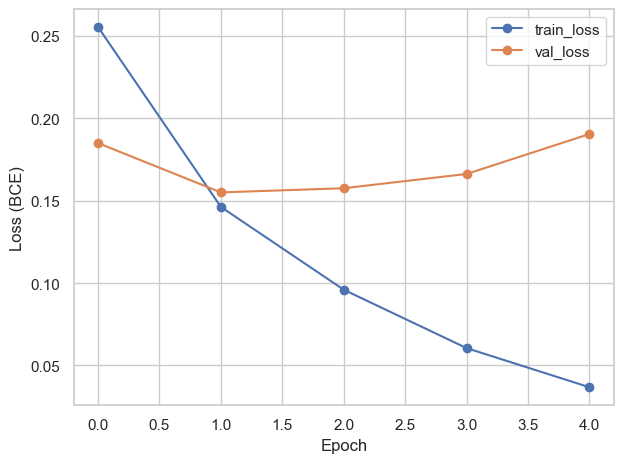

In [44]:
plt.figure()
for key, values in history.items():
    plt.plot(values, marker="o", label=key)

plt.xlabel("Epoch")
plt.ylabel("Loss (BCE)")
plt.legend()
plt.tight_layout()
plt.show()

> 💡 Watch the two curves. If **val loss** starts rising while **train loss**
> keeps falling, the model is **overfitting**.

## Evaluation 📈

We predict on the **test set**, turn logits into probabilities with the sigmoid,
then into classes with a `0.5` threshold.

Because the classes are imbalanced, **accuracy is not enough** — a model that
predicts *"neutral"* for everything would already look "accurate". So we also
report the **F1-score**, the **classification report**, and the **confusion
matrix**.

In [45]:
def evaluate(model, loader):
    """Return (y_true, y_pred) over a whole DataLoader."""
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for xb, lengths, yb in loader:
            xb = xb.to(device)
            logits = model(xb, lengths)
            probs  = torch.sigmoid(logits).cpu().numpy().ravel()
            preds  = (probs >= 0.5).astype(int)
            y_pred.extend(preds.tolist())
            y_true.extend(yb.numpy().ravel().astype(int).tolist())
    return np.array(y_true), np.array(y_pred)

y_true, y_pred = evaluate(model, test_loader)

print("Accuracy:", round(accuracy_score(y_true, y_pred), 4))
print("F1-score:", round(f1_score(y_true, y_pred), 4))
print()
print(classification_report(y_true, y_pred))

Accuracy: 0.9524
F1-score: 0.5682

              precision    recall  f1-score   support

           0       0.96      0.99      0.97      5945
           1       0.78      0.45      0.57       448

    accuracy                           0.95      6393
   macro avg       0.87      0.72      0.77      6393
weighted avg       0.95      0.95      0.95      6393



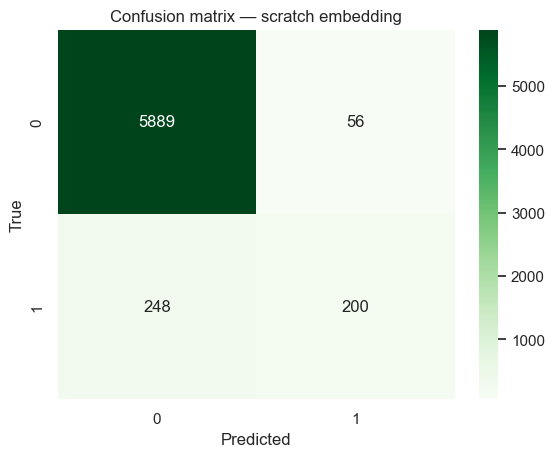

In [46]:
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion matrix — scratch embedding")
plt.show()

> 🔎 Look at the confusion matrix: how many **hate-speech** tweets (class 1) did
> the model actually catch? On imbalanced data this is what the **F1-score**
> captures and accuracy hides.

## Bonus: pre-trained GloVe embeddings 🌍

So far the model learned its word vectors **from scratch**, from ~30k tweets.
But we can start from embeddings already trained on **billions** of words.

**GloVe** (Global Vectors, from Stanford) is such a set of pre-trained vectors.
They capture **semantic relationships**, famously:

- `king − man + woman ≈ queen` 👑
- `paris − france + germany ≈ berlin`

We will use the small **50-dimensional** variant and plug it into our
`nn.Embedding`.

> ⏳ The download is ~800 MB, so run the next cell **early** — it can take a few
> minutes.

In [47]:
!wget -q http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q -o glove.6B.zip glove.6B.50d.txt

'wget' is not recognized as an internal or external command,
operable program or batch file.
'unzip' is not recognized as an internal or external command,
operable program or batch file.


In [48]:
import os, urllib.request, zipfile

GLOVE_URL = "https://nlp.stanford.edu/data/glove.6B.zip"
ZIP_PATH  = "glove.6B.zip"
TARGET    = "glove.6B.50d.txt"

if not os.path.exists(TARGET):
    if not os.path.exists(ZIP_PATH):
        print("Downloading GloVe (~800 MB, this can take a few minutes)...")
        urllib.request.urlretrieve(GLOVE_URL, ZIP_PATH)
    print("Extracting", TARGET, "...")
    with zipfile.ZipFile(ZIP_PATH) as z:
        z.extract(TARGET)          # vybalí jen ten 50d soubor
    print("Done.")
else:
    print(TARGET, "already present.")

Extracting glove.6B.50d.txt ...
Done.


### Load the vectors into a dictionary

In [49]:
embeddings_index = {}
with open("glove.6B.50d.txt", "r", encoding="utf-8") as f:
    for line in f:
        word, coefs = line.split(maxsplit=1)
        embeddings_index[word] = np.fromstring(coefs, "f", sep=" ")

print("Found", len(embeddings_index), "word vectors.")
print("Vector for 'analysis' has shape:", embeddings_index["analysis"].shape)

Found 400000 word vectors.
Vector for 'analysis' has shape: (50,)


### Build an embedding matrix aligned to *our* vocabulary

We create a matrix of shape `(vocab_size, 50)` where **row `i` is the GloVe
vector for the word with index `i`** in our vocabulary. Words not found in GloVe
(and `<pad>`/`<unk>`) stay as zeros.

In [50]:
GLOVE_DIM = 50
embedding_matrix = np.zeros((len(vocab), GLOVE_DIM), dtype=np.float32)

hits = misses = 0
for word, i in word2idx.items():
    vec = embeddings_index.get(word)
    if vec is not None:
        embedding_matrix[i] = vec
        hits += 1
    else:
        misses += 1

print(f"Converted {hits} words ({misses} misses / OOV).")

Converted 8353 words (1647 misses / OOV).


### A GloVe-powered model

We reuse the **same architecture**, but the embedding is initialised from GloVe
and **frozen** (`freeze=True`) — we do not update it during training.

In [51]:
class GloVeRNNClassifier(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim, pad_idx, freeze=True):
        super().__init__()
        weights = torch.tensor(embedding_matrix)
        self.embedding = nn.Embedding.from_pretrained(weights, freeze=freeze, padding_idx=pad_idx)
        embed_dim = weights.shape[1]
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.gru  = nn.GRU(hidden_dim, hidden_dim, batch_first=True)
        self.fc1  = nn.Linear(hidden_dim, 64)
        self.drop = nn.Dropout(0.3)
        self.fc2  = nn.Linear(64, 1)

    def forward(self, x, lengths):
        emb    = self.embedding(x)
        packed = pack_padded_sequence(emb, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, _ = self.lstm(packed)
        _, h_n = self.gru(packed_out)
        z = torch.relu(self.fc1(h_n[-1]))
        z = self.drop(z)
        return self.fc2(z)

glove_model = GloVeRNNClassifier(embedding_matrix, HIDDEN_DIM, PAD_IDX, freeze=True).to(device)
print(glove_model)

GloVeRNNClassifier(
  (embedding): Embedding(10000, 50, padding_idx=0)
  (lstm): LSTM(50, 64, batch_first=True)
  (gru): GRU(64, 64, batch_first=True)
  (fc1): Linear(in_features=64, out_features=64, bias=True)
  (drop): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)


### Train it (same loop, packaged into a helper)

Now that you have seen the loop written out, we wrap it into a small
`train_model` function and reuse it.

In [52]:
def train_model(model, train_loader, val_loader, n_epochs=5, lr=1e-3, ckpt="best.pt"):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": []}
    best_val = float("inf")

    for epoch in range(n_epochs):
        model.train()
        running = 0.0
        for xb, lengths, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb, lengths), yb)
            loss.backward()
            optimizer.step()
            running += loss.item() * xb.size(0)
        train_loss = running / len(train_loader.dataset)

        model.eval()
        running = 0.0
        with torch.no_grad():
            for xb, lengths, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                running += criterion(model(xb, lengths), yb).item() * xb.size(0)
        val_loss = running / len(val_loader.dataset)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        if val_loss < best_val:
            best_val = val_loss
            torch.save(model.state_dict(), ckpt)
        print(f"epoch {epoch+1:2d} | train {train_loss:.4f} | val {val_loss:.4f}")

    model.load_state_dict(torch.load(ckpt))
    return history

glove_history = train_model(glove_model, train_loader, val_loader, n_epochs=5, ckpt="best_glove.pt")

epoch  1 | train 0.2767 | val 0.1891
epoch  2 | train 0.1773 | val 0.1686
epoch  3 | train 0.1582 | val 0.1523
epoch  4 | train 0.1465 | val 0.1521
epoch  5 | train 0.1388 | val 0.1467


In [53]:
y_true_g, y_pred_g = evaluate(glove_model, test_loader)

print("=== Scratch embedding ===")
print("Accuracy:", round(accuracy_score(y_true, y_pred), 4), "| F1:", round(f1_score(y_true, y_pred), 4))
print("\n=== GloVe (frozen) ===")
print("Accuracy:", round(accuracy_score(y_true_g, y_pred_g), 4), "| F1:", round(f1_score(y_true_g, y_pred_g), 4))

=== Scratch embedding ===
Accuracy: 0.9524 | F1: 0.5682

=== GloVe (frozen) ===
Accuracy: 0.9504 | F1: 0.5345


> 🤔 Which one wins on **F1**? GloVe was trained on general text (Wikipedia),
> while tweets are a very specific, noisy domain — so pre-trained vectors are not
> guaranteed to be better here.

# Activities ✏️

Now it is your turn to change the code. Re-run training and compare the
**F1-score** each time.

## Activity 1 — LSTM vs. GRU 🔀

In `RNNClassifier`, our sequence goes `LSTM → GRU`. Experiment with the
recurrent core:

- use **only an LSTM** (remove the GRU), or **only a GRU**,
- change `HIDDEN_DIM` (e.g. `32`, `128`),
- add `num_layers=2` to `nn.LSTM` / `nn.GRU`.

Which variant gives the best **F1** on the test set?

## Activity 2 — Bidirectional RNN ↔️

A **bidirectional** RNN reads the sequence **both forwards and backwards**, which
often helps for text.

- Set `bidirectional=True` in the recurrent layer.
- ⚠️ Remember: the hidden size of the output then **doubles**, so the next layer
  must expect `hidden_dim * 2` inputs, and `h_n` will have **2 rows per layer**
  (concatenate the last forward and backward states).

Build it, train it, and compare.

## Activity 3 — Fine-tune the GloVe embedding 🔧

We used GloVe **frozen**. Now let the model adapt the vectors to tweets:

- rebuild the model with `freeze=False`,
- train and compare the **F1** against both the scratch model and the frozen GloVe.

## Activity 4 — Bigger GloVe & your own architecture 🚀

- Download a **higher-dimensional** GloVe and rebuild
  the embedding matrix.
- You may combine anything you learned (bidirectional, `num_layers`, dropout,
  `pos_weight`, threshold tuning…) to push the **F1-score** as high as you can.